In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [13]:
time = 100000
x_starts = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
y_start = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
r = [0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
a = [0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
b = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
c = [0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
x0 = 1.2
y0 = 0.5
a0 = 0.2
b0 = 1.1
c0 = 4.0

In [14]:
def exponential(r, x_start, time):
    val = [x_start]
    for i in range(1, time):
        val.append(r * val[-1])
    return val

In [15]:
def logistic(r, x_start, time):
    val = [x_start]
    for i in range(1, time):
        val.append(r * val[-1] * (1 - val[-1]))
    return val

In [16]:
def moran(r, x_start, time):
    val = [x_start]
    for i in range(1, time):
        val.append(val[-1] * math.exp(r * (1 - val[-1])))
    return val

In [17]:
def good_bad(a, b, c, x_start, y_start, time):
    val = [x_start]
    y = [y_start]
    for i in range(1, time):
        val.append(b * val[-1] * math.exp(-a * y[-1]))
        y.append(c * val[-2] * (1 - math.exp(-a * y[-1])))
    return val, y

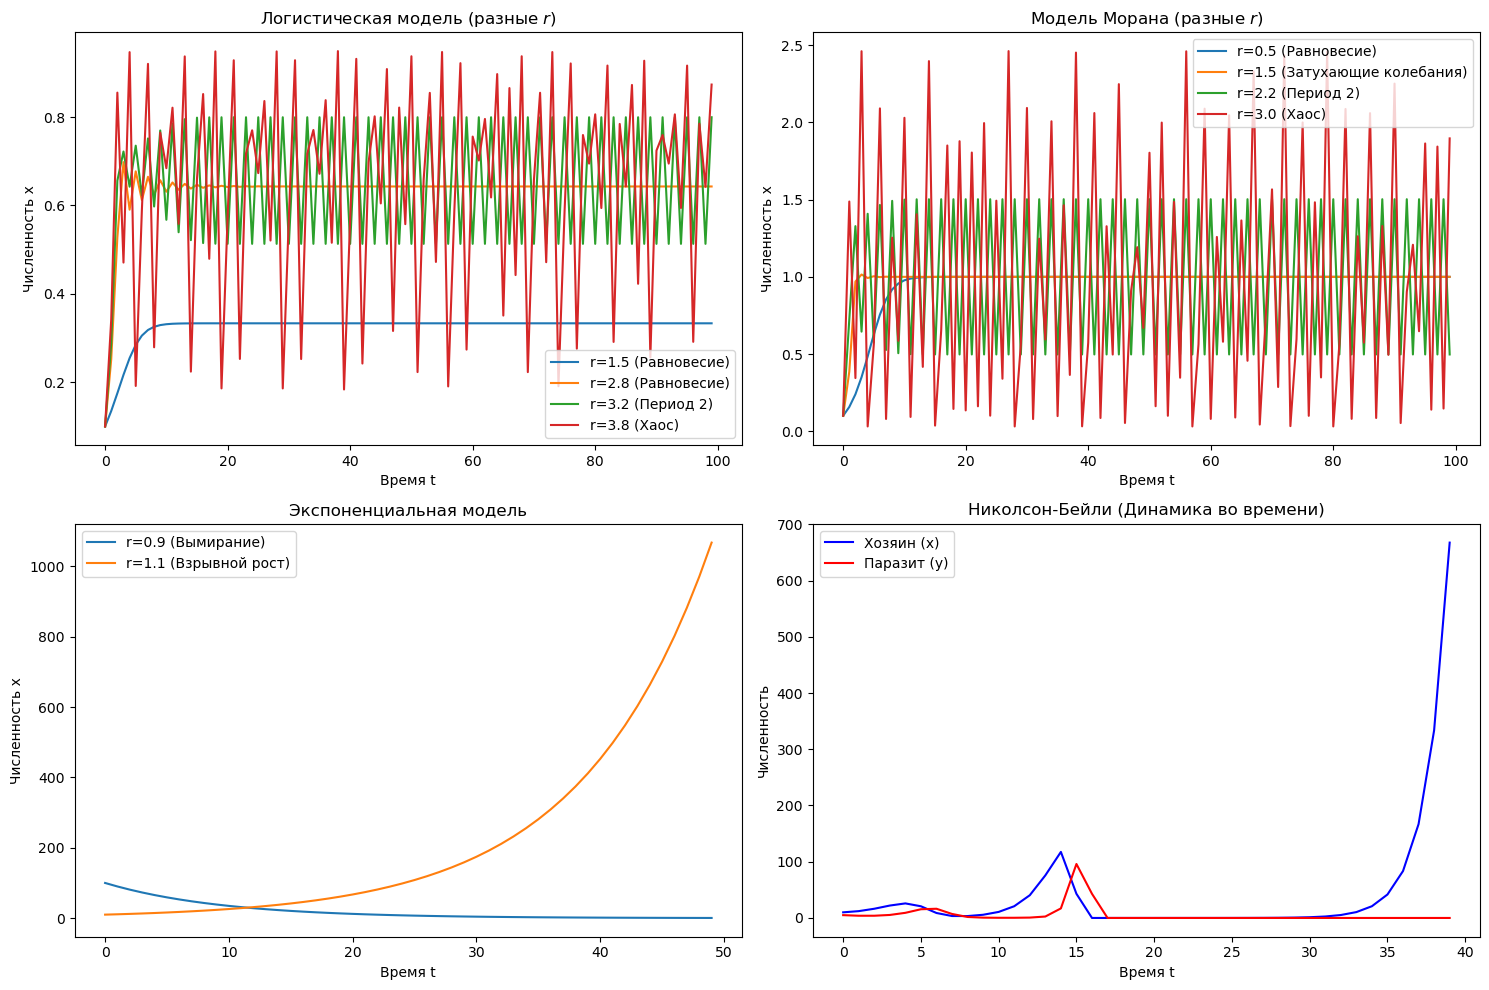

In [18]:

plt.rcParams['figure.figsize'] = (15, 10)

time_steps = 100
t = range(time_steps)

plt.subplot(2, 2, 1)
plt.title("Логистическая модель (разные $r$)")

plt.plot(logistic(1.5, 0.1, time_steps), label="r=1.5 (Равновесие)")
plt.plot(logistic(2.8, 0.1, time_steps), label="r=2.8 (Равновесие)")

plt.plot(logistic(3.2, 0.1, time_steps), label="r=3.2 (Период 2)")
plt.plot(logistic(3.8, 0.1, time_steps), label="r=3.8 (Хаос)")
plt.xlabel("Время t")
plt.ylabel("Численность x")
plt.legend()

plt.subplot(2, 2, 2)
plt.title("Модель Морана (разные $r$)")
plt.plot(moran(0.5, 0.1, time_steps), label="r=0.5 (Равновесие)")
plt.plot(moran(1.5, 0.1, time_steps), label="r=1.5 (Затухающие колебания)")
plt.plot(moran(2.2, 0.1, time_steps), label="r=2.2 (Период 2)")
plt.plot(moran(3.0, 0.1, time_steps), label="r=3.0 (Хаос)")
plt.xlabel("Время t")
plt.ylabel("Численность x")
plt.legend()

plt.subplot(2, 2, 3)
plt.title("Экспоненциальная модель")
plt.plot(exponential(0.9, 100, 50), label="r=0.9 (Вымирание)")
plt.plot(exponential(1.1, 10, 50), label="r=1.1 (Взрывной рост)")
plt.xlabel("Время t")
plt.ylabel("Численность x")
plt.legend()

plt.subplot(2, 2, 4)
plt.title("Николсон-Бейли (Динамика во времени)")
x_nb, y_nb = good_bad(a=0.1, b=2.0, c=1.0, x_start=10, y_start=5, time=40)
plt.plot(x_nb, label="Хозяин (x)", color='blue')
plt.plot(y_nb, label="Паразит (y)", color='red')
plt.xlabel("Время t")
plt.ylabel("Численность")
plt.legend()

plt.tight_layout()
plt.show()

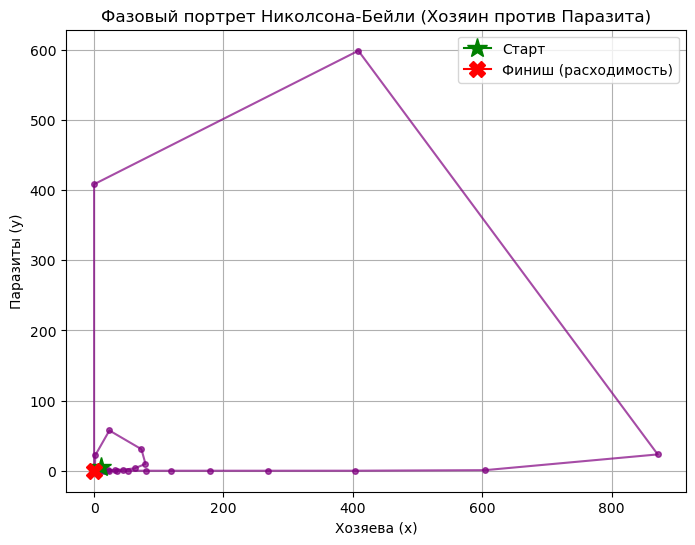

In [19]:
plt.figure(figsize=(8, 6))
plt.title("Фазовый портрет Николсона-Бейли (Хозяин против Паразита)")
x_nb, y_nb = good_bad(a=0.05, b=1.5, c=1.0, x_start=10, y_start=5, time=60)

plt.plot(x_nb, y_nb, marker='o', linestyle='-', markersize=4, color='purple', alpha=0.7)
plt.plot(x_nb[0], y_nb[0], marker='*', color='green', markersize=15, label="Старт")
plt.plot(x_nb[-1], y_nb[-1], marker='X', color='red', markersize=12, label="Финиш (расходимость)")

plt.xlabel("Хозяева (x)")
plt.ylabel("Паразиты (y)")
plt.legend()
plt.grid(True)
plt.show()

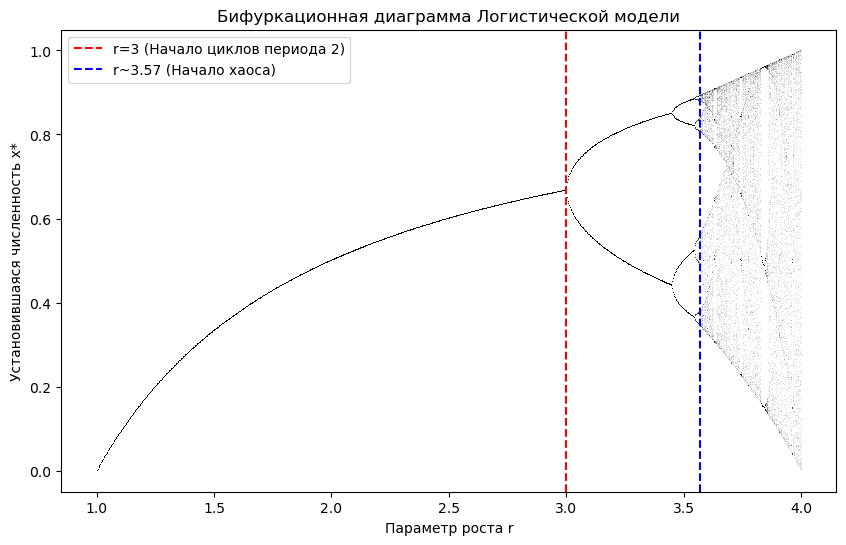

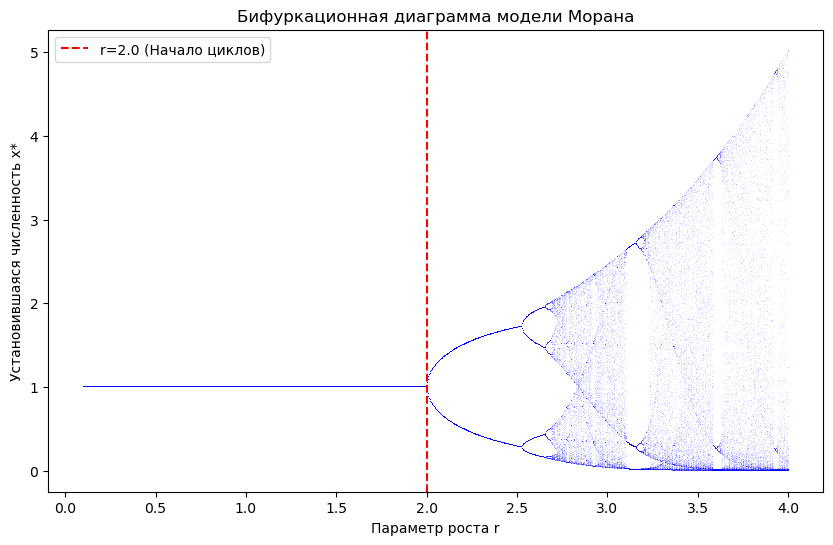

In [20]:
def plot_logistic_bifurcation():
    r_values = np.linspace(1.0, 4.0, 1000)
    iterations = 1000
    last = 100

    x = 1e-5 * np.ones(1000)

    plt.figure(figsize=(10, 6))
    plt.title("Бифуркационная диаграмма Логистической модели")

    for i in range(iterations):
        x = r_values * x * (1 - x)
        if i >= (iterations - last):
            plt.plot(r_values, x, ',k', alpha=0.1)

    plt.xlabel("Параметр роста r")
    plt.ylabel("Установившаяся численность x*")

    plt.axvline(3.0, color='red', linestyle='--', label='r=3 (Начало циклов периода 2)')
    plt.axvline(3.57, color='blue', linestyle='--', label='r~3.57 (Начало хаоса)')
    plt.legend()
    plt.show()


def plot_moran_bifurcation():
    r_values = np.linspace(0.1, 4.0, 1000)
    iterations = 1000
    last = 100

    x = 0.1 * np.ones(1000)

    plt.figure(figsize=(10, 6))
    plt.title("Бифуркационная диаграмма модели Морана")

    for i in range(iterations):
        x = x * np.exp(r_values * (1 - x))
        if i >= (iterations - last):
            plt.plot(r_values, x, ',b', alpha=0.1)

    plt.xlabel("Параметр роста r")
    plt.ylabel("Установившаяся численность x*")

    plt.axvline(2.0, color='red', linestyle='--', label='r=2.0 (Начало циклов)')
    plt.legend()
    plt.show()


plot_logistic_bifurcation()
plot_moran_bifurcation()